In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/Cleaned/feature_engineered_dataco.csv')

In [3]:
df.shape

(180519, 64)

In [4]:
df.head

<bound method NDFrame.head of             Type  Days for shipping (real)  Days for shipment (scheduled)  \
0          DEBIT                         3                              4   
1       TRANSFER                         5                              4   
2           CASH                         4                              4   
3          DEBIT                         3                              4   
4        PAYMENT                         2                              4   
...          ...                       ...                            ...   
180514      CASH                         4                              4   
180515     DEBIT                         3                              2   
180516  TRANSFER                         5                              4   
180517   PAYMENT                         3                              4   
180518   PAYMENT                         4                              4   

        Benefit per order  Sales per customer

In [5]:
df['order date (DateOrders)'] = pd.to_datetime(
    df['order date (DateOrders)']
)

df['shipping date (DateOrders)'] = pd.to_datetime(
    df['shipping date (DateOrders)']
)

In [6]:
df[['order date (DateOrders)', 'shipping date (DateOrders)']].dtypes

order date (DateOrders)       datetime64[ns]
shipping date (DateOrders)    datetime64[ns]
dtype: object

In [7]:
total_revenue = df['Sales'].sum()

total_profit = df['Order Profit Per Order'].sum()

total_orders = df['Order Id'].nunique()

total_customers = df['Customer Id'].nunique()

total_quantity = df['Order Item Quantity'].sum()

average_order_value = total_revenue / total_orders

average_delivery_delay = df['Delivery Delay'].mean()

late_delivery_rate = (
    (df['Delivery Performance'] == 'Late').mean() * 100
)

average_profit_margin = df['Profit Margin (%)'].mean()

print("Total Revenue:", total_revenue)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Total Quantity Sold:", total_quantity)
print("Average Order Value:", average_order_value)
print("Average Delivery Delay:", average_delivery_delay)
print("Late Delivery Rate:", late_delivery_rate)
print("Average Profit Margin:", average_profit_margin)

Total Revenue: 36784735.01337984
Total Profit: 3966902.974050357
Total Orders: 65752
Total Customers: 20652
Total Quantity Sold: 384079
Average Order Value: 559.4466330055335
Average Delivery Delay: 0.5658074773292562
Late Delivery Rate: 57.279289160697765
Average Profit Margin: 10.832484724599627


In [8]:
business_summary = pd.DataFrame({
    'Metric': [
        'Total Revenue',
        'Total Profit',
        'Total Orders',
        'Total Customers',
        'Total Quantity Sold',
        'Average Order Value',
        'Average Delivery Delay',
        'Late Delivery Rate (%)',
        'Average Profit Margin (%)'
    ],
    
    'Value': [
        total_revenue,
        total_profit,
        total_orders,
        total_customers,
        total_quantity,
        average_order_value,
        average_delivery_delay,
        late_delivery_rate,
        average_profit_margin
    ]
})

business_summary

,Metric,Value
0,Total Revenue,3.678474e+07
1,Total Profit,3.966903e+06
2,Total Orders,6.575200e+04
3,Total Customers,2.065200e+04
4,Total Quantity Sold,3.840790e+05
5,Average Order Value,5.594466e+02
6,Average Delivery Delay,5.658075e-01
7,Late Delivery Rate (%),5.727929e+01
8,Average Profit Margin (%),1.083248e+01


### How has revenue changed over time?

In [9]:
monthly_sales = (
    df.groupby('Order Year')['Sales']
      .sum()
)

monthly_sales

Order Year
2015    1.234083e+07
2016    1.230382e+07
2017    1.180844e+07
2018    3.316501e+05
Name: Sales, dtype: float64

In [10]:
monthly_sales = (
    df.groupby(
        ['Order Year', 'Order Month']
    )['Sales']
    .sum()
    .reset_index()
)

monthly_sales.head()

,Order Year,Order Month,Sales
0,2015,April,1.014463e+06
1,2015,August,1.029495e+06
2,2015,December,1.057841e+06
3,2015,February,9.270099e+05
4,2015,January,1.051590e+06


In [11]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_sales['Order Month'] = pd.Categorical(
    monthly_sales['Order Month'],
    categories=month_order,
    ordered=True
)


In [12]:
monthly_sales = monthly_sales.sort_values(
    ['Order Year', 'Order Month']
)

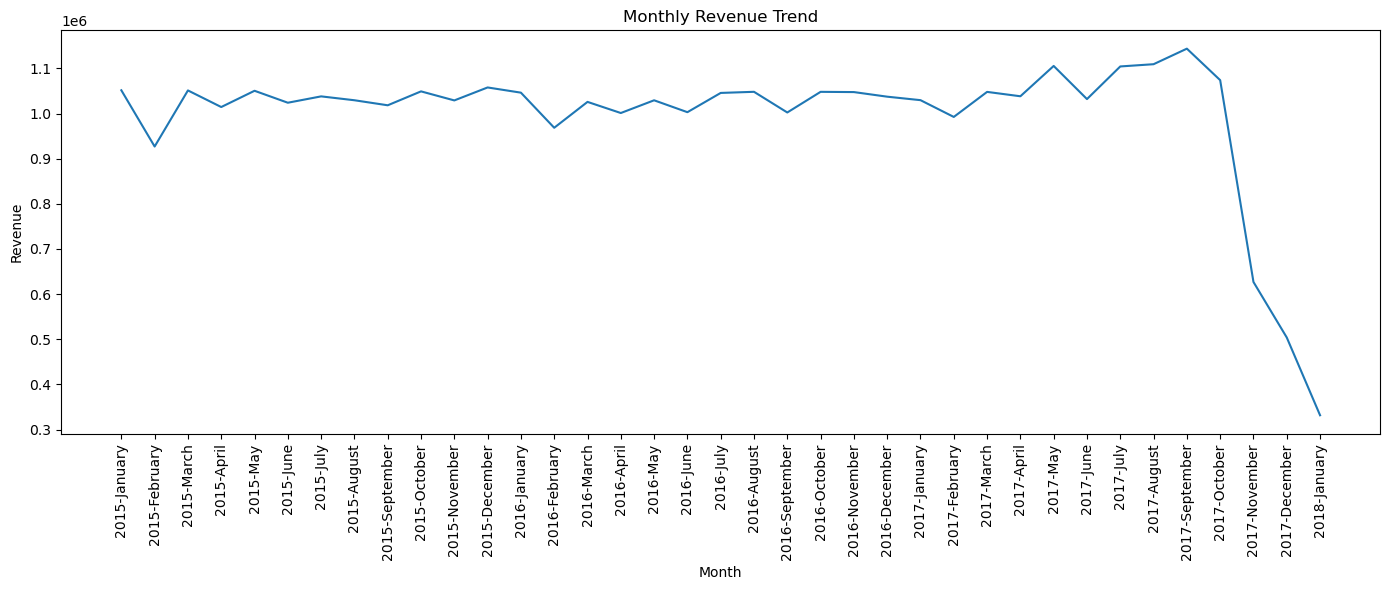

In [13]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales['Order Year'].astype(str) + '-' +
    monthly_sales['Order Month'].astype(str),
    monthly_sales['Sales']
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [14]:
monthly_sales.tail(10)

,Order Year,Order Month,Sales
24,2017,April,1.038322e+06
32,2017,May,1.105485e+06
30,2017,June,1.032086e+06
29,2017,July,1.104373e+06
25,2017,August,1.109337e+06
35,2017,September,1.143775e+06
34,2017,October,1.073994e+06
33,2017,November,6.269144e+05
26,2017,December,5.039108e+05
36,2018,January,3.316501e+05


In [15]:
df['order date (DateOrders)'].min(), df['order date (DateOrders)'].max()

(Timestamp('2015-01-01 00:00:00'), Timestamp('2018-01-31 23:38:00'))

In [16]:
monthly_coverage = (
    df.groupby(
        df['order date (DateOrders)'].dt.to_period('M')
    )['order date (DateOrders)']
    .agg(
        first_order='min',
        last_order='max',
        order_count='count'
    )
    .reset_index()
)

monthly_coverage.tail(6)

,order date (DateOrders),first_order,last_order,order_count
31,2017-08,2017-08-01 00:15:00,2017-08-31 23:41:00,5305
32,2017-09,2017-09-01 00:02:00,2017-09-30 23:59:00,5189
33,2017-10,2017-10-01 00:20:00,2017-10-31 23:46:00,2255
34,2017-11,2017-11-01 00:07:00,2017-11-30 23:44:00,2055
35,2017-12,2017-12-01 00:05:00,2017-12-31 23:52:00,2124
36,2018-01,2018-01-01 00:13:00,2018-01-31 23:38:00,2123


In [17]:
df['order date (DateOrders)'].max()

Timestamp('2018-01-31 23:38:00')

In [18]:
monthly_coverage.tail(6)

,order date (DateOrders),first_order,last_order,order_count
31,2017-08,2017-08-01 00:15:00,2017-08-31 23:41:00,5305
32,2017-09,2017-09-01 00:02:00,2017-09-30 23:59:00,5189
33,2017-10,2017-10-01 00:20:00,2017-10-31 23:46:00,2255
34,2017-11,2017-11-01 00:07:00,2017-11-30 23:44:00,2055
35,2017-12,2017-12-01 00:05:00,2017-12-31 23:52:00,2124
36,2018-01,2018-01-01 00:13:00,2018-01-31 23:38:00,2123


In [19]:
monthly_revenue_analysis = (
    df.groupby(
        ['Order Year', 'Order Month']
    )
    .agg(
        Revenue=('Sales', 'sum'),
        Orders=('Order Id', 'nunique'),
        Average_Order_Value=('Sales', 'mean')
    )
    .reset_index()
)

monthly_revenue_analysis.tail(8)

,Order Year,Order Month,Revenue,Orders,Average_Order_Value
29,2017,July,1.104373e+06,1776,207.667048
30,2017,June,1.032086e+06,1676,208.460208
31,2017,March,1.048005e+06,1782,195.998650
32,2017,May,1.105485e+06,1763,207.915238
33,2017,November,6.269144e+05,2055,305.067827
34,2017,October,1.073994e+06,2101,476.272359
35,2017,September,1.143775e+06,1723,220.423031
36,2018,January,3.316501e+05,2123,156.217671


In [20]:
monthly_revenue_analysis['Revenue_per_Order'] = (
    monthly_revenue_analysis['Revenue'] /
    monthly_revenue_analysis['Orders']
)

monthly_revenue_analysis.tail(8)

,Order Year,Order Month,Revenue,Orders,Average_Order_Value,Revenue_per_Order
29,2017,July,1.104373e+06,1776,207.667048,621.831847
30,2017,June,1.032086e+06,1676,208.460208,615.803395
31,2017,March,1.048005e+06,1782,195.998650,588.105938
32,2017,May,1.105485e+06,1763,207.915238,627.047829
33,2017,November,6.269144e+05,2055,305.067827,305.067827
34,2017,October,1.073994e+06,2101,476.272359,511.182375
35,2017,September,1.143775e+06,1723,220.423031,663.827689
36,2018,January,3.316501e+05,2123,156.217671,156.217671


In [21]:
order_level = (
    df.groupby('Order Id')
    .agg(
        Order_Date=('order date (DateOrders)', 'min'),
        Order_Revenue=('Sales', 'sum')
    )
    .reset_index()
)

order_level['Order Year'] = order_level['Order_Date'].dt.year
order_level['Order Month'] = order_level['Order_Date'].dt.month_name()

In [22]:
monthly_order_analysis = (
    order_level.groupby(
        ['Order Year', 'Order Month']
    )
    .agg(
        Revenue=('Order_Revenue', 'sum'),
        Orders=('Order Id', 'count'),
        Average_Order_Value=('Order_Revenue', 'mean')
    )
    .reset_index()
)

In [23]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_order_analysis['Order Month'] = pd.Categorical(
    monthly_order_analysis['Order Month'],
    categories=month_order,
    ordered=True
)

monthly_order_analysis = monthly_order_analysis.sort_values(
    ['Order Year', 'Order Month']
)

In [24]:
monthly_order_analysis.tail(8)

,Order Year,Order Month,Revenue,Orders,Average_Order_Value
30,2017,June,1.032086e+06,1676,615.803395
29,2017,July,1.104373e+06,1776,621.831847
25,2017,August,1.109337e+06,1768,627.453151
35,2017,September,1.143775e+06,1723,663.827689
34,2017,October,1.073994e+06,2101,511.182375
33,2017,November,6.269144e+05,2055,305.067827
26,2017,December,5.039108e+05,2124,237.246148
36,2018,January,3.316501e+05,2123,156.217671


## Does order size explain the AOV decline?

In [25]:
order_size_month = pd.crosstab(
    df['Order Size'],
    df['Order Month'],
    normalize='columns'
) * 100

order_size_month[['September', 'December', 'January']]

Order Month,September,December,January
Order Size,,,
Large,24.888631,23.464431,21.475054
Medium,50.519724,46.662488,48.222927
Small,24.591646,29.873081,30.302019


In [26]:
order_size_month = pd.crosstab(
    df['Order Size'],
    [df['Order Year'], df['Order Month']],
    normalize='columns'
) * 100

order_size_month[[ 
    (2017, 'September'),
    (2017, 'December'),
    (2018, 'January')
]]

Order Year        2017                  2018
Order Month  September   December    January
Order Size                                  
Large        30.410484  29.990584  14.507772
Medium       48.968973  24.811676  32.171455
Small        20.620543  45.197740  53.320772

In [27]:
order_size_revenue = (
    df.groupby(['Order Year', 'Order Month', 'Order Size'])
    .agg(
        Revenue=('Sales', 'sum'),
        Orders=('Order Id', 'nunique')
    )
    .reset_index()
)

order_size_revenue['Revenue_per_Order'] = (
    order_size_revenue['Revenue'] /
    order_size_revenue['Orders']
)

In [28]:
order_size_revenue[
    (
        (order_size_revenue['Order Year'] == 2017) &
        (order_size_revenue['Order Month'].isin(['September', 'December']))
    ) |
    (
        (order_size_revenue['Order Year'] == 2018) &
        (order_size_revenue['Order Month'] == 'January')
    )
]

,Order Year,Order Month,Order Size,Revenue,Orders,Revenue_per_Order
78,2017,December,Large,356385.873720,637,559.475469
79,2017,December,Medium,113540.943235,527,215.447710
80,2017,December,Small,33984.000387,960,35.400000
105,2017,September,Large,577767.748355,1059,545.578610
106,2017,September,Medium,476440.268482,1361,350.066325
107,2017,September,Small,89567.090787,812,110.304299
108,2018,January,Large,120610.681642,308,391.593122
109,2018,January,Medium,162844.493150,683,238.425319
110,2018,January,Small,48194.940365,1132,42.575036


## What is causing the lower order value?

In [29]:
order_value_driver = (
    df.groupby('Order Id')
    .agg(
        Order_Date=('order date (DateOrders)', 'min'),
        Order_Revenue=('Sales', 'sum'),
        Quantity=('Order Item Quantity', 'sum')
    )
    .reset_index()
)

order_value_driver['Order Year'] = (
    order_value_driver['Order_Date'].dt.year
)

order_value_driver['Order Month'] = (
    order_value_driver['Order_Date'].dt.month_name()
)

order_value_driver['Revenue_per_Item'] = (
    order_value_driver['Order_Revenue'] /
    order_value_driver['Quantity']
)

In [30]:
order_value_monthly = (
    order_value_driver[
        (
            (order_value_driver['Order Year'] == 2017) &
            (order_value_driver['Order Month'].isin(['September', 'December']))
        ) |
        (
            (order_value_driver['Order Year'] == 2018) &
            (order_value_driver['Order Month'] == 'January')
        )
    ]
    .groupby(['Order Year', 'Order Month'])
    .agg(
        Orders=('Order Id', 'count'),
        Average_Order_Revenue=('Order_Revenue', 'mean'),
        Average_Quantity=('Quantity', 'mean'),
        Average_Revenue_per_Item=('Revenue_per_Item', 'mean')
    )
    .reset_index()
)

order_value_monthly


,Order Year,Order Month,Orders,Average_Order_Revenue,Average_Quantity,Average_Revenue_per_Item
0,2017,December,2124,237.246148,1.000000,237.246148
1,2017,September,1723,663.827689,6.095183,134.972386
2,2018,January,2123,156.217671,1.000000,156.217671


In [31]:
df[['Order Id', 'Order Item Quantity']].head(20)

,Order Id,Order Item Quantity
0,77202,1
1,75939,1
2,75938,1
3,75937,1
4,75936,1
5,75935,1
6,75934,1
7,75933,1
8,75932,1
9,75931,1


In [32]:
df['Order Item Quantity'].describe()

count    180519.000000
mean          2.127638
std           1.453451
min           1.000000
25%           1.000000
50%           1.000000
75%           3.000000
max           5.000000
Name: Order Item Quantity, dtype: float64

In [33]:
df.groupby('Order Id')['Order Item Quantity'].sum().describe()

count    65752.000000
mean         5.841328
std          4.169632
min          1.000000
25%          2.000000
50%          5.000000
75%          9.000000
max         24.000000
Name: Order Item Quantity, dtype: float64

In [34]:
monthly_quantity_check = (
    df.groupby(
        ['Order Year', 'Order Month']
    )
    .agg(
        Total_Quantity=('Order Item Quantity', 'sum'),
        Unique_Orders=('Order Id', 'nunique')
    )
    .reset_index()
)

monthly_quantity_check['Quantity_per_Order'] = (
    monthly_quantity_check['Total_Quantity'] /
    monthly_quantity_check['Unique_Orders']
)

monthly_quantity_check.tail(8)

,Order Year,Order Month,Total_Quantity,Unique_Orders,Quantity_per_Order
29,2017,July,11091,1776,6.244932
30,2017,June,10194,1676,6.082339
31,2017,March,11676,1782,6.552189
32,2017,May,11033,1763,6.258083
33,2017,November,2055,2055,1.000000
34,2017,October,2490,2101,1.185150
35,2017,September,10502,1723,6.095183
36,2018,January,2123,2123,1.000000


In [35]:
df[
    (
        (df['Order Year'] == 2017) &
        (df['Order Month'] == 'December')
    ) |
    (
        (df['Order Year'] == 2018) &
        (df['Order Month'] == 'January')
    )
][
    ['Order Id', 'Order Item Quantity', 'Order Year', 'Order Month']
].head(20)

,Order Id,Order Item Quantity,Order Year,Order Month
0,77202,1,2018,January
1,75939,1,2018,January
2,75938,1,2018,January
3,75937,1,2018,January
4,75936,1,2018,January
5,75935,1,2018,January
6,75934,1,2018,January
7,75933,1,2018,January
8,75932,1,2018,January
9,75931,1,2018,January


In [36]:
df[
    (
        (df['Order Year'] == 2017) &
        (df['Order Month'] == 'December')
    ) |
    (
        (df['Order Year'] == 2018) &
        (df['Order Month'] == 'January')
    )
]['Order Item Quantity'].value_counts().sort_index()

Order Item Quantity
1    4247
Name: count, dtype: int64

## Overall Profitability

In [37]:
order_rows_monthly = (
    df.groupby(['Order Year', 'Order Month'])
    .agg(
        Total_Rows=('Order Id', 'size'),
        Unique_Orders=('Order Id', 'nunique')
    )
    .reset_index()
)

order_rows_monthly['Rows_per_Order'] = (
    order_rows_monthly['Total_Rows'] /
    order_rows_monthly['Unique_Orders']
)

order_rows_monthly.tail(8)

,Order Year,Order Month,Total_Rows,Unique_Orders,Rows_per_Order
29,2017,July,5318,1776,2.994369
30,2017,June,4951,1676,2.954057
31,2017,March,5347,1782,3.000561
32,2017,May,5317,1763,3.015882
33,2017,November,2055,2055,1.000000
34,2017,October,2255,2101,1.073298
35,2017,September,5189,1723,3.011608
36,2018,January,2123,2123,1.000000


# Profitability Analysis

## Is the company generating healthy profit from its sales, and where are profitability problems concentrated?

In [38]:
total_revenue = df['Sales'].sum()
total_profit = df['Order Profit Per Order'].sum() 

overall_profit_margin =(
    total_profit / total_revenue
)*100

profitability_summary ={
    'Total Revenue': total_revenue, 
    'Total Profit': total_profit,
    'Overall Profit Margin (%)': overall_profit_margin 
}

profitability_summary

{'Total Revenue': np.float64(36784735.01337984),
 'Total Profit': np.float64(3966902.974050357),
 'Overall Profit Margin (%)': np.float64(10.78410099354382)}

## Profitability by Market

### Does profitability vary significantly across markets?

In [39]:
profit_by_market = (
    df.groupby('Market')
    .agg(
        Revenue=('Sales', 'sum'),
        Profit=('Order Profit Per Order', 'sum'),
        Orders=('Order Id', 'nunique')
    )
    .reset_index()
)

profit_by_market['Profit Margin (%)'] = (
    profit_by_market['Profit'] /
    profit_by_market['Revenue']
) * 100

profit_by_market = profit_by_market.sort_values(
    'Profit',
    ascending=False
)

profit_by_market

,Market,Revenue,Profit,Orders,Profit Margin (%)
1,Europe,1.087240e+07,1.169443e+06,18561,10.756073
2,LATAM,1.027761e+07,1.123322e+06,17181,10.929791
3,Pacific Asia,8.273744e+06,8.577534e+05,17577,10.367174
4,USCA,5.066529e+06,5.643138e+05,8579,11.138075
0,Africa,2.294453e+06,2.520712e+05,3854,10.986113


In [40]:
profit_by_segment = (
    df.groupby('Customer Segment')
    .agg(
        Revenue=('Sales', 'sum'),
        Profit=('Order Profit Per Order', 'sum'),
        Orders=('Order Id', 'nunique')
    )
    .reset_index()
)

profit_by_segment['Profit Margin (%)'] = (
    profit_by_segment['Profit'] /
    profit_by_segment['Revenue']
) * 100

profit_by_segment = profit_by_segment.sort_values(
    'Profit',
    ascending=False
)

profit_by_segment

,Customer Segment,Revenue,Profit,Orders,Profit Margin (%)
0,Consumer,1.909579e+07,2.073488e+06,34119,10.858350
1,Corporate,1.116841e+07,1.202575e+06,19856,10.767650
2,Home Office,6.520538e+06,6.908403e+05,11777,10.594836


## Are higher discounts associated with lower profitability?

In [41]:
profit_by_discount = (
    df.groupby('Discount Category')
    .agg(
        Revenue=('Sales', 'sum'),
        Profit=('Order Profit Per Order', 'sum'),
        Orders=('Order Id', 'nunique')
    )
    .reset_index()
)

profit_by_discount['Profit Margin (%)'] = (
    profit_by_discount['Profit'] /
    profit_by_discount['Revenue']
) * 100

profit_by_discount = profit_by_discount.sort_values(
    'Profit Margin (%)'
)

profit_by_discount

,Discount Category,Revenue,Profit,Orders,Profit Margin (%)
0,High,4.088565e+06,3.692095e+05,17152,9.030295
2,Medium,1.430770e+07,1.454009e+06,43309,10.162418
1,Low,1.634610e+07,1.876272e+06,46789,11.478412
3,No Discount,2.042369e+06,2.674124e+05,9400,13.093245


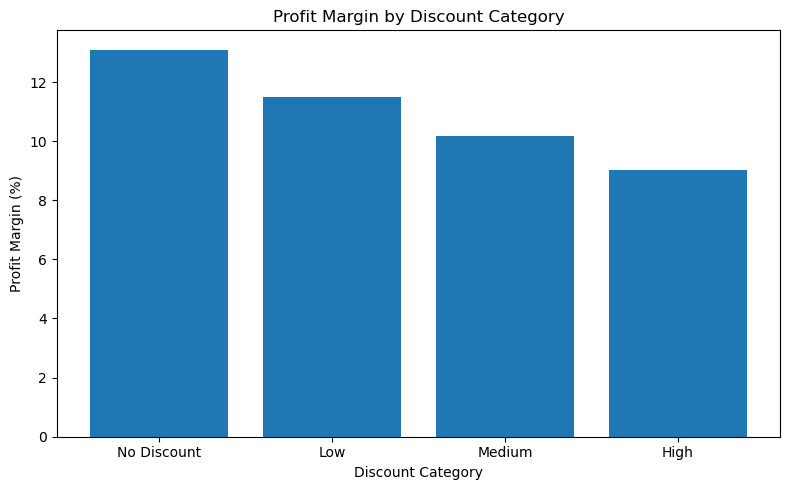

In [42]:

discount_order = [
    'No Discount',
    'Low',
    'Medium',
    'High'
]

plot_data = profit_by_discount.copy()

plot_data['Discount Category'] = pd.Categorical(
    plot_data['Discount Category'],
    categories=discount_order,
    ordered=True
)

plot_data = plot_data.sort_values('Discount Category')

plt.figure(figsize=(8, 5))

plt.bar(
    plot_data['Discount Category'],
    plot_data['Profit Margin (%)']
)

plt.xlabel('Discount Category')
plt.ylabel('Profit Margin (%)')
plt.title('Profit Margin by Discount Category')

plt.tight_layout()
plt.show()

### Profitability Finding

Profitability varies only slightly across markets and customer segments, with profit margins remaining close to the overall margin of 10.78%.

A stronger relationship is observed between discount level and profitability. Profit margin decreases consistently as the discount category increases, from 13.09% for orders with no discount to 9.03% for highly discounted orders.

This indicates that higher discounting is associated with lower profitability.

### Business Recommendation

Discounting should be managed carefully, particularly for highly discounted orders. Rather than eliminating discounts, the business could evaluate whether higher discounts generate sufficient additional sales volume or customer value to compensate for the reduction in margin.

### Analytical Caveat

The analysis identifies an association between discount level and profit margin, not a causal relationship. Product mix, customer characteristics, and other factors may also influence profitability.

# Delivery & Logistics

## Delivery & Logistics

In [43]:
df['Delivery Performance'].value_counts(dropna=False)

Delivery Performance
Late       103400
Early       43366
On Time     33753
Name: count, dtype: int64

In [44]:
delivery_by_market = (
    pd.crosstab(
        df['Market'], 
        df['Delivery Performance'], 
        normalize='index'
    )*100
)

delivery_by_market

Delivery Performance,Early,Late,On Time
Market,,,
Africa,23.712760,56.810746,19.476494
Europe,24.024914,57.687256,18.287829
LATAM,24.303214,57.022134,18.674652
Pacific Asia,23.919050,57.317014,18.763936
USCA,23.764487,57.149502,19.086011


## Does the shipping mode affect delivery performance?

In [45]:
df['Shipping Mode'].value_counts()

Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64

In [46]:
delivery_by_shipping = (
    pd.crosstab(
        df['Shipping Mode'], 
        df['Delivery Performance'],
        normalize= 'index'
    )*100
)
delivery_by_shipping

Delivery Performance,Early,Late,On Time
Shipping Mode,,,
First Class,0.000000,100.000000,0.000000
Same Day,0.000000,47.827873,52.172127
Second Class,0.000000,79.730804,20.269196
Standard Class,40.246121,39.768171,19.985708


In [47]:
shipping_delivery_metrics = (
    df.groupby('Shipping Mode')
    .agg(
        Orders=('Order Id', 'nunique'),
        Avg_Scheduled_Days=('Days for shipment (scheduled)', 'mean'),
        Avg_Actual_Days=('Days for shipping (real)', 'mean')
    )
    .reset_index()
)

shipping_delivery_metrics

,Shipping Mode,Orders,Avg_Scheduled_Days,Avg_Actual_Days
0,First Class,10079,1.0,2.000000
1,Same Day,3571,0.0,0.478279
2,Second Class,12778,2.0,3.990828
3,Standard Class,39324,4.0,3.995907


In [48]:
shipping_delivery_metrics['Average_Delay'] = (
    shipping_delivery_metrics['Avg_Actual_Days'] -
    shipping_delivery_metrics['Avg_Scheduled_Days']
)

shipping_delivery_metrics

,Shipping Mode,Orders,Avg_Scheduled_Days,Avg_Actual_Days,Average_Delay
0,First Class,10079,1.0,2.000000,1.000000
1,Same Day,3571,0.0,0.478279,0.478279
2,Second Class,12778,2.0,3.990828,1.990828
3,Standard Class,39324,4.0,3.995907,-0.004093


Delivery performance varies substantially by shipping mode. First Class and Second Class have the highest late-delivery rates, corresponding with actual shipping times that exceed their scheduled delivery targets. Standard Class has the lowest late-delivery rate, while Same Day still has nearly half of shipments classified as late.

## Does late delivery affect profitability?

In [49]:
profit_by_delivery = (
    df.groupby('Delivery Performance')
    .agg(
        Revenue=('Sales', 'sum'),
        Profit=('Order Profit Per Order', 'sum'),
        Orders=('Order Id', 'nunique')
    )
    .reset_index()
)

profit_by_delivery['Profit Margin (%)'] = (
    profit_by_delivery['Profit'] /
    profit_by_delivery['Revenue']
) * 100

profit_by_delivery

,Delivery Performance,Revenue,Profit,Orders,Profit Margin (%)
0,Early,8.874649e+06,9.744130e+05,15787,10.979735
1,Late,2.102519e+07,2.231967e+06,37698,10.615681
2,On Time,6.884901e+06,7.605233e+05,12267,11.046250


In [50]:
delay_by_shipping = (
    df.groupby('Shipping Mode')
    .agg(
        Orders=('Order Id', 'nunique'),
        Average_Delay=('Delivery Delay', 'mean'),
        Median_Delay=('Delivery Delay', 'median'),
        Maximum_Delay=('Delivery Delay', 'max')
    )
    .reset_index()
)

delay_by_shipping

,Shipping Mode,Orders,Average_Delay,Median_Delay,Maximum_Delay
0,First Class,10079,1.000000,1.0,1
1,Same Day,3571,0.478279,0.0,1
2,Second Class,12778,1.990828,2.0,4
3,Standard Class,39324,-0.004093,0.0,2


### Delivery & Logistics — Key Findings

The overall late-delivery rate is approximately 57%, and late deliveries are widespread across markets, with market-level late rates ranging from approximately 56.8% to 57.7%. This indicates that the delivery problem is not concentrated in a specific geographic market.

Shipping mode shows substantially greater variation in delivery performance. First Class has a 100% late-delivery rate, while Second Class has a 79.7% late-delivery rate. Standard Class has the lowest late-delivery rate at approximately 39.8%.

Delay severity further highlights Second Class as a concern. Second Class shipments are delayed by approximately 2 days on average, compared with 1 day for First Class and approximately 0 days for Standard Class.

Late deliveries are associated with a slightly lower profit margin (10.62%) than on-time deliveries (11.05%), but the difference is relatively small. Therefore, delivery performance should primarily be treated as an operational issue rather than a major direct profitability driver.

### Business Recommendation

Management should investigate the operational processes behind First Class and particularly Second Class shipments, focusing on why actual shipping times exceed their scheduled service levels. Improving fulfillment and carrier performance for these modes could reduce late deliveries without necessarily requiring changes to the broader market strategy.

# Customer & Product Analysis

## Customer Value by Segment

### Which customer segments contribute the most revenue and customer value?

In [51]:
customer_segment_value = (
    df.groupby('Customer Segment')
    .agg(
        Revenue=('Sales', 'sum'),
        Profit=('Order Profit Per Order', 'sum'),
        Orders=('Order Id', 'nunique'),
        Customers=('Customer Id', 'nunique')
    )
    .reset_index()
)

customer_segment_value['Average Order Value'] = (
    customer_segment_value['Revenue'] /
    customer_segment_value['Orders']
)

customer_segment_value['Orders per Customer'] = (
    customer_segment_value['Orders'] /
    customer_segment_value['Customers']
)

customer_segment_value

,Customer Segment,Revenue,Profit,Orders,Customers,Average Order Value,Orders per Customer
0,Consumer,1.909579e+07,2.073488e+06,34119,10695,559.682000,3.190182
1,Corporate,1.116841e+07,1.202575e+06,19856,6239,562.470127,3.182561
2,Home Office,6.520538e+06,6.908403e+05,11777,3718,553.667149,3.167563


### Customer Segment Finding

Consumer generates the highest revenue and profit, primarily because it has the largest customer base. However, average order value is very similar across Consumer ($559.68), 

Corporate ($562.47), 

and Home Office ($553.67), while orders per customer also remain closely aligned at approximately 3.17–3.19 orders per customer.

This suggests that customer segment size, rather than substantially different purchasing behavior, is the primary reason for the difference in revenue contribution.

### Is revenue concentrated among a relatively small group of customers?

In [52]:
customer_value = (
    df.groupby('Customer Id')
    .agg(
        Lifetime_Revenue=('Sales', 'sum'),
        Order_Count=('Order Id', 'nunique')
    )
    .reset_index()
)

customer_value['Average_Order_Value'] = (
    customer_value['Lifetime_Revenue'] /
    customer_value['Order_Count']
)

customer_value = customer_value.sort_values(
    'Lifetime_Revenue',
    ascending=False
)

customer_value.head(10)

,Customer Id,Lifetime_Revenue,Order_Count,Average_Order_Value
782,791,10524.170178,13,809.551552
9295,9371,9299.030207,11,845.366382
8694,8766,9296.140186,11,845.103653
1636,1657,9223.710152,11,838.519105
2612,2641,9130.920224,11,830.083657
1271,1288,9019.110199,12,751.592517
3672,3710,9019.100208,14,644.221443
4209,4249,8918.850134,13,686.065395
5603,5654,8904.950211,15,593.663347
5573,5624,8761.980183,12,730.165015


In [53]:
total_customer_revenue = customer_value['Lifetime_Revenue'].sum()

top_10_revenue = (
    customer_value.head(10)['Lifetime_Revenue'].sum()
)

top_10_share = (
    top_10_revenue / total_customer_revenue
) * 100

top_10_share

np.float64(0.2503700566215058)

In [54]:
top_10_percent_count = int(len(customer_value) * 0.10)

top_10_percent_revenue = (
    customer_value.head(top_10_percent_count)['Lifetime_Revenue'].sum()
)

top_10_percent_share = (
    top_10_percent_revenue / total_customer_revenue
) * 100

top_10_percent_count, top_10_percent_share

(2065, np.float64(29.187465362351055))

In [55]:
bottom_50_count = int(len(customer_value) * 0.50)

bottom_50_revenue = (
    customer_value.tail(bottom_50_count)['Lifetime_Revenue'].sum()
)

bottom_50_share = (
    bottom_50_revenue / total_customer_revenue
) * 100

bottom_50_count, bottom_50_share

(10326, np.float64(11.280094415787666))

### Customer Revenue Concentration

Revenue is moderately concentrated among higher-value customers but is not dependent on a small number of individual accounts. The top 10 customers contribute only approximately 0.25% of total customer revenue, while the top 10% of customers account for approximately 29.19%.

In contrast, the bottom 50% of customers contribute approximately 11.28% of revenue. This indicates that higher-value customers represent an important revenue opportunity, while the business remains relatively diversified across individual customers.

### Business Recommendation

Customer retention and targeted engagement should prioritize the higher-value portion of the customer base, while broad customer acquisition and retention strategies can continue to address the wider customer population.

## Product Performance

In [56]:
[col for col in df.columns if 'Category' in col]

['Category Id',
 'Category Name',
 'Product Category Id',
 'Profit Category',
 'Discount Category']

### Which product categories drive revenue and profit, and are high-revenue categories also profitable?

In [57]:
profit_by_category = (
    df.groupby('Category Name')
    .agg(
        Revenue=('Sales', 'sum'),
        Profit=('Order Profit Per Order', 'sum'),
        Orders=('Order Id', 'nunique')
    )
    .reset_index()
)

profit_by_category['Profit Margin (%)'] = (
    profit_by_category['Profit'] /
    profit_by_category['Revenue']
) * 100

profit_by_category = profit_by_category.sort_values(
    'Revenue',
    ascending=False
)

profit_by_category

,Category Name,Revenue,Profit,Orders,Profit Margin (%)
18,Fishing,6.929654e+06,756220.767190,15164,10.912822
12,Cleats,4.431943e+06,494636.919791,20386,11.160724
9,Camping & Hiking,4.118426e+06,427455.568106,12299,10.379101
10,Cardio Equipment,3.694843e+06,383011.098485,11355,10.366099
47,Women's Apparel,3.147800e+06,350421.029567,17869,11.132252
46,Water Sports,3.113845e+06,325146.960038,13758,10.441977
34,Men's Footwear,2.891758e+06,311902.820214,18783,10.785925
30,Indoor/Outdoor Games,2.888994e+06,318451.430554,16623,11.022918
38,Shop By Sport,1.309522e+06,129813.960315,10136,9.913079
13,Computers,6.630000e+05,69656.810171,442,10.506306


In [58]:
top_revenue_categories = (
    profit_by_category
    .sort_values('Revenue', ascending=False)
    .head(10)
)

top_revenue_categories[
    [
        'Category Name',
        'Revenue',
        'Profit',
        'Orders',
        'Profit Margin (%)'
    ]
]

,Category Name,Revenue,Profit,Orders,Profit Margin (%)
18,Fishing,6.929654e+06,756220.767190,15164,10.912822
12,Cleats,4.431943e+06,494636.919791,20386,11.160724
9,Camping & Hiking,4.118426e+06,427455.568106,12299,10.379101
10,Cardio Equipment,3.694843e+06,383011.098485,11355,10.366099
47,Women's Apparel,3.147800e+06,350421.029567,17869,11.132252
46,Water Sports,3.113845e+06,325146.960038,13758,10.441977
34,Men's Footwear,2.891758e+06,311902.820214,18783,10.785925
30,Indoor/Outdoor Games,2.888994e+06,318451.430554,16623,11.022918
38,Shop By Sport,1.309522e+06,129813.960315,10136,9.913079
13,Computers,6.630000e+05,69656.810171,442,10.506306


In [59]:
top_revenue_categories[
    top_revenue_categories['Profit Margin (%)'] < overall_profit_margin
]

,Category Name,Revenue,Profit,Orders,Profit Margin (%)
9,Camping & Hiking,4.118426e+06,427455.568106,12299,10.379101
10,Cardio Equipment,3.694843e+06,383011.098485,11355,10.366099
46,Water Sports,3.113845e+06,325146.960038,13758,10.441977
38,Shop By Sport,1.309522e+06,129813.960315,10136,9.913079
13,Computers,6.630000e+05,69656.810171,442,10.506306


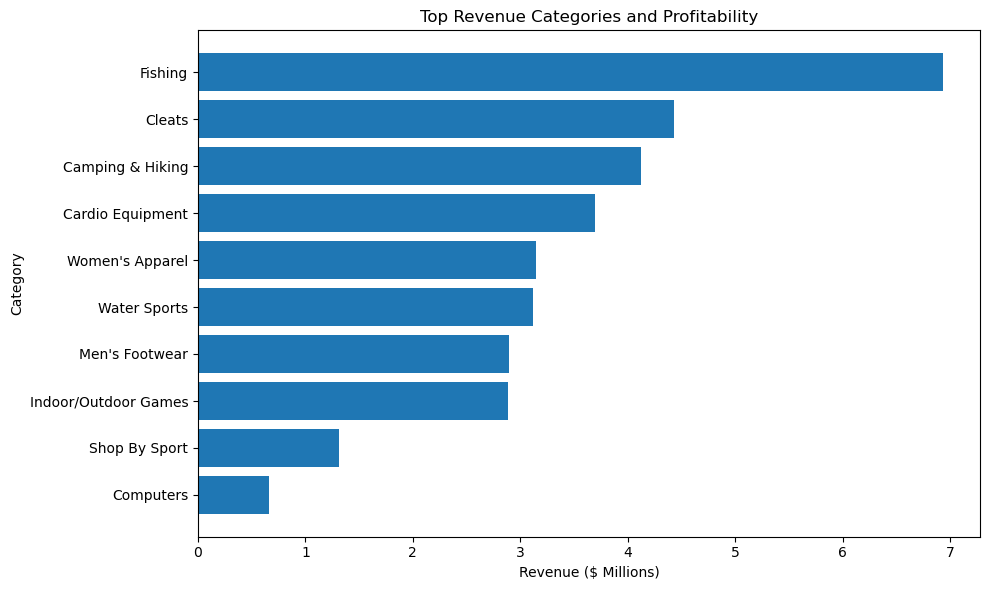

In [60]:
import matplotlib.pyplot as plt

plot_data = top_revenue_categories.sort_values(
    'Revenue',
    ascending=True
)

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.barh(
    plot_data['Category Name'],
    plot_data['Revenue'] / 1_000_000
)

ax1.set_xlabel('Revenue ($ Millions)')
ax1.set_ylabel('Category')
ax1.set_title('Top Revenue Categories and Profitability')

plt.tight_layout()
plt.show()

### Product Category Finding

Fishing is the largest revenue-generating category, with approximately $6.93M in revenue and 

$756K in profit. Cleats is the second-largest category by revenue and also maintains an above-average profit margin.

Several other major revenue categories, including Camping & Hiking, Cardio Equipment, and Water Sports, have profit margins below the overall business margin of 10.78%. These categories generate substantial revenue but convert it into profit less efficiently.

### Business Recommendation

Management should prioritize margin optimization in high-revenue categories operating below the overall margin benchmark. Potential areas for investigation include discounting, product-level margins, and fulfillment costs. At the same time, strong categories such as Fishing and Cleats should be protected from margin erosion while maintaining their revenue contribution.

### Analytical Caveat

A category having a below-average margin does not automatically mean it should receive less investment. Revenue scale, customer demand, strategic importance, and operational costs should also be considered before making a resource-allocation decision.

In [61]:
sql_df = df.copy()

sql_df = sql_df.rename(columns={
    'Type': 'type',
    'Days for shipping (real)': 'days_for_shipping_real',
    'Days for shipment (scheduled)': 'days_for_shipment_scheduled',
    'Delivery Status': 'delivery_status',
    'Late_delivery_risk': 'late_delivery_risk',
    'Category Id': 'category_id',
    'Category Name': 'category_name',
    'Customer City': 'customer_city',
    'Customer Country': 'customer_country',
    'Customer Id': 'customer_id',
    'Customer Segment': 'customer_segment',
    'Customer State': 'customer_state',
    'Customer Zipcode': 'customer_zipcode',
    'Department Id': 'department_id',
    'Department Name': 'department_name',
    'Latitude': 'latitude',
    'Longitude': 'longitude',
    'Market': 'market',
    'Order City': 'order_city',
    'Order Country': 'order_country',
    'order date (DateOrders)': 'order_date',
    'Order Id': 'order_id',
    'Order Item Cardprod Id': 'order_item_cardprod_id',
    'Order Item Discount': 'order_item_discount',
    'Order Item Discount Rate': 'order_item_discount_rate',
    'Order Item Id': 'order_item_id',
    'Order Item Product Price': 'order_item_product_price',
    'Order Item Profit Ratio': 'order_item_profit_ratio',
    'Order Item Quantity': 'order_item_quantity',
    'Sales': 'sales',
    'Order Item Total': 'order_item_total',
    'Order Profit Per Order': 'order_profit_per_order',
    'Order Region': 'order_region',
    'Order State': 'order_state',
    'Order Status': 'order_status',
    'Product Card Id': 'product_card_id',
    'Product Category Id': 'product_category_id',
    'Product Name': 'product_name',
    'Product Price': 'product_price',
    'Product Status': 'product_status',
    'shipping date (DateOrders)': 'shipping_date',
    'Shipping Mode': 'shipping_mode',
    'Delivery Delay': 'delivery_delay',
    'Profit Margin (%)': 'profit_margin',
    'Order Year': 'order_year',
    'Order Month': 'order_month',
    'Order Quarter': 'order_quarter',
    'Delivery Performance': 'delivery_performance',
    'Order Size': 'order_size',
    'Discount Category': 'discount_category',
    'Profit Segment': 'profit_segment',
    'Customer Lifetime Revenue': 'customer_lifetime_revenue',
    'Customer Order Count': 'customer_order_count',
    'Customer Average Order Value': 'customer_average_order_value',
    'Order Age': 'order_age'
})

In [62]:
sql_df.columns.tolist()

['type',
 'days_for_shipping_real',
 'days_for_shipment_scheduled',
 'Benefit per order',
 'Sales per customer',
 'delivery_status',
 'late_delivery_risk',
 'category_id',
 'category_name',
 'customer_city',
 'customer_country',
 'customer_id',
 'customer_segment',
 'customer_state',
 'customer_zipcode',
 'department_id',
 'department_name',
 'latitude',
 'longitude',
 'market',
 'order_city',
 'order_country',
 'Order Customer Id',
 'order_date',
 'order_id',
 'order_item_cardprod_id',
 'order_item_discount',
 'order_item_discount_rate',
 'order_item_id',
 'order_item_product_price',
 'order_item_profit_ratio',
 'order_item_quantity',
 'sales',
 'order_item_total',
 'order_profit_per_order',
 'order_region',
 'order_state',
 'order_status',
 'product_card_id',
 'product_category_id',
 'product_name',
 'product_price',
 'product_status',
 'shipping_date',
 'shipping_mode',
 'delivery_delay',
 'profit_margin',
 'order_year',
 'order_month',
 'order_quarter',
 'Weekday',
 'Weekend Order'

In [ ]:
sql_df.to_csv(
    "../data/Processed/feature_engineered_dataco_sql.csv",
    index=False
)

In [63]:
sql_df.shape

(180519, 64)

In [64]:
columns_to_remove = [
    'Benefit per order',
    'Sales per customer',
    'Order Customer Id',
    'Weekday',
    'Weekend Order',
    'High Value Order',
    'Profit Category',
    'Shipping Efficiency',
    'Revenue Contribution (%)'
]

sql_df = sql_df.drop(columns=columns_to_remove)

sql_df.shape

(180519, 55)

In [65]:
sql_df.columns.tolist()

['type',
 'days_for_shipping_real',
 'days_for_shipment_scheduled',
 'delivery_status',
 'late_delivery_risk',
 'category_id',
 'category_name',
 'customer_city',
 'customer_country',
 'customer_id',
 'customer_segment',
 'customer_state',
 'customer_zipcode',
 'department_id',
 'department_name',
 'latitude',
 'longitude',
 'market',
 'order_city',
 'order_country',
 'order_date',
 'order_id',
 'order_item_cardprod_id',
 'order_item_discount',
 'order_item_discount_rate',
 'order_item_id',
 'order_item_product_price',
 'order_item_profit_ratio',
 'order_item_quantity',
 'sales',
 'order_item_total',
 'order_profit_per_order',
 'order_region',
 'order_state',
 'order_status',
 'product_card_id',
 'product_category_id',
 'product_name',
 'product_price',
 'product_status',
 'shipping_date',
 'shipping_mode',
 'delivery_delay',
 'profit_margin',
 'order_year',
 'order_month',
 'order_quarter',
 'delivery_performance',
 'order_size',
 'discount_category',
 'profit_segment',
 'customer_lif

In [66]:
pip install psycopg2-binary sqlalchemy

Note: you may need to restart the kernel to use updated packages.


In [67]:
from sqlalchemy import create_engine

# PostgreSQL connection
username = "postgres"
host = "localhost"
port = "5432"
database = "dataco_analytics"
password = "1012"

engine = create_engine(
    f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
)

# Load SQL-ready DataFrame into PostgreSQL
table_name = "dataco_supply_chain"

sql_df.to_sql(
    table_name,
    engine,
    if_exists="replace",
    index=False
)

print(f"Data successfully loaded into '{table_name}'")

Data successfully loaded into 'dataco_supply_chain'
